<a href="https://colab.research.google.com/github/Cesar-moncada/Int.-Artificial-y-redes-neuronales-013/blob/main/AF7_RNP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diego alan López Neváres 2057757 Angel Servando Martinez Martinez 1960203 César Adrián Moncada Chavira 2177904 Ricardo Joshua Sánchez Olazarán 1996201 David Rangel Constante 2177973 L,M,V V6

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Cargar MNIST
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [3]:
# Normalizar datos (0-255 → 0-1)
train_data = train_data / 255.0
test_data = test_data / 255.0

# Convertir imágenes (28x28) a vectores (784)
train_data = train_data.reshape(-1, 28*28)
test_data = test_data.reshape(-1, 28*28)

# (Opcional) convertir etiquetas a categóricas si usas Keras
train_labels_cat = to_categorical(train_labels)
test_labels_cat = to_categorical(test_labels)

print("Nuevo shape:", train_data.shape)


Nuevo shape: (60000, 784)


In [4]:
# Definir modelo
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # arquitectura propuesta
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

# Entrenar modelo
model.fit(train_data, train_labels)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42)

In [5]:
# Predicciones en test
predictions = model.predict(test_data)

# Exactitud
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9769


In [6]:
# Evaluación equivalente a evaluate
print("Exactitud en test:", model.score(test_data, test_labels))

Exactitud en test: 0.9769


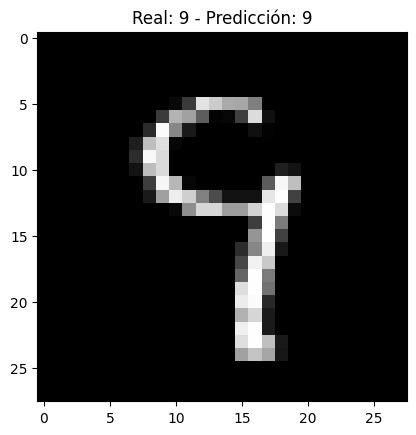

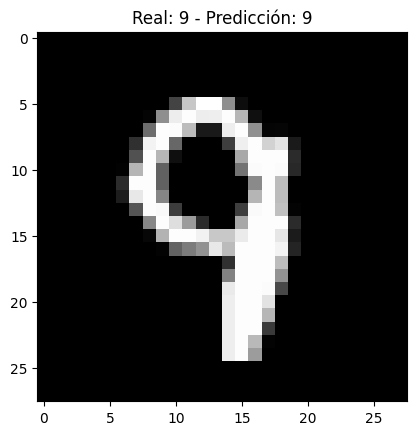

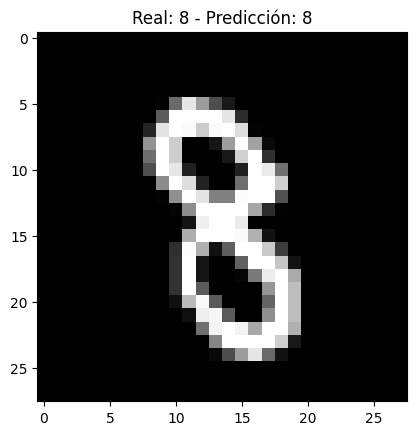

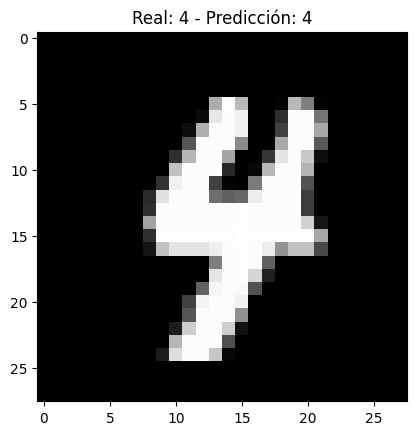

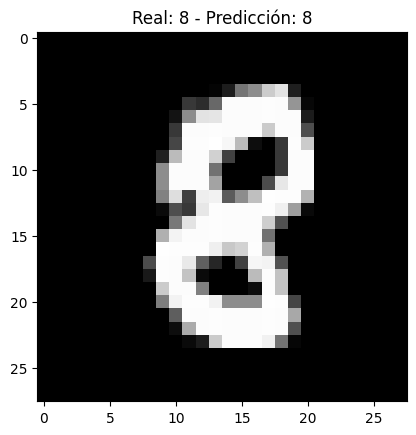

In [7]:
import random

indices = random.sample(range(len(test_data)), 5)

for idx in indices:
    plt.imshow(test_data[idx].reshape(28,28), cmap='gray')
    plt.title(f"Real: {test_labels[idx]} - Predicción: {model.predict([test_data[idx]])[0]}")
    plt.show()